 Ejercicio 4 
Media teórica: 3.2600
Media empírica: 3.4630
Varianza teórica: 7.3004
Varianza empírica: 9.2726

Prueba KS para dos muestras: estadístico=0.0290, p-value=0.7947
KS: No se rechaza H0 - Las muestras vienen de la misma distribución.

Prueba chi-cuadrado: estadístico=19.3396, p-value=0.6243, grados de libertad=22
Chi-cuadrado: No se rechaza H0 - Las muestras vienen de la misma distribución.


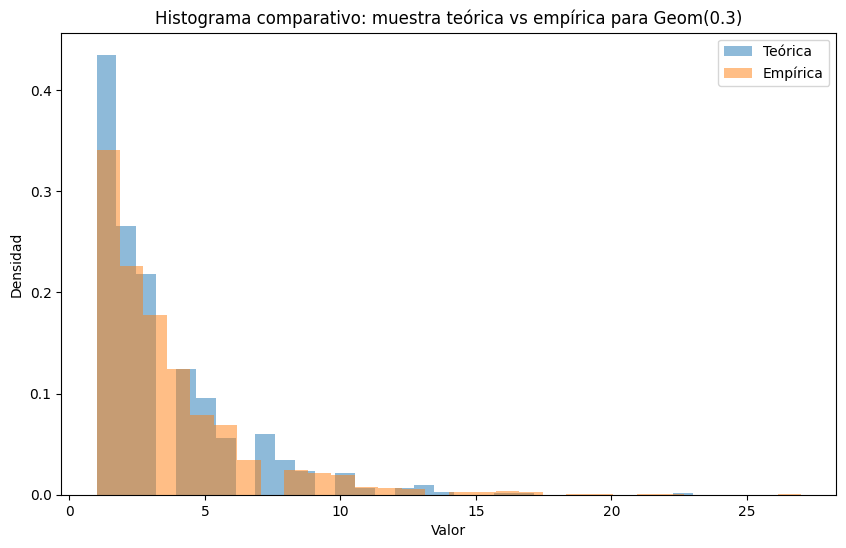

In [5]:
import random
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parámetros
p = 0.3
N = 1000

# Generar muestra teórica con scipy.stats.geom
np.random.seed(42)  # Para reproducibilidad
theoretical_sample = stats.geom.rvs(p, size=N)

# Generar muestra empírica con transformada integral (método inverso)
random.seed(42)  # Para reproducibilidad
empirical_sample = []
for i in range(N):
    u = random.random()
    k = 1
    while True:
        if 1 - (1 - p)**k >= u:
            empirical_sample.append(k)
            break
        k += 1

# Convertir a arrays numpy
theoretical_sample = np.array(theoretical_sample)
empirical_sample = np.array(empirical_sample)

# Estadísticos descriptivos
print(" Ejercicio 4 ")
print(f"Media teórica: {np.mean(theoretical_sample):.4f}")
print(f"Media empírica: {np.mean(empirical_sample):.4f}")
print(f"Varianza teórica: {np.var(theoretical_sample):.4f}")
print(f"Varianza empírica: {np.var(empirical_sample):.4f}")

# Prueba de Kolmogorov-Smirnov para dos muestras
ks_stat, ks_pvalue = stats.ks_2samp(theoretical_sample, empirical_sample)
print(f"\nPrueba KS para dos muestras: estadístico={ks_stat:.4f}, p-value={ks_pvalue:.4f}")
alpha = 0.05
if ks_pvalue > alpha:
    print("KS: No se rechaza H0 - Las muestras vienen de la misma distribución.")
else:
    print("KS: Se rechaza H0 - Las muestras no vienen de la misma distribución.")

# Prueba de chi-cuadrado para dos muestras
# Encontrar todos los valores únicos en ambas muestras
all_values = np.concatenate([theoretical_sample, empirical_sample])
unique_values = np.unique(all_values)

# Contar frecuencias para cada valor en cada muestra
freq_theo = np.bincount(theoretical_sample, minlength=unique_values.max()+1)[unique_values]
freq_emp = np.bincount(empirical_sample, minlength=unique_values.max()+1)[unique_values]

# Construir tabla de contingencia
table = np.array([freq_theo, freq_emp])

# Realizar prueba de chi-cuadrado de homogeneidad
chi2, p_value, dof, expected = stats.chi2_contingency(table)
print(f"\nPrueba chi-cuadrado: estadístico={chi2:.4f}, p-value={p_value:.4f}, grados de libertad={dof}")
if p_value > alpha:
    print("Chi-cuadrado: No se rechaza H0 - Las muestras vienen de la misma distribución.")
else:
    print("Chi-cuadrado: Se rechaza H0 - Las muestras no vienen de la misma distribución.")

# Histograma comparativo
plt.figure(figsize=(10, 6))
plt.hist(theoretical_sample, bins=30, density=True, alpha=0.5, label='Teórica')
plt.hist(empirical_sample, bins=30, density=True, alpha=0.5, label='Empírica')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.title('Histograma comparativo: muestra teórica vs empírica para Geom(0.3)')
plt.legend()
plt.show()

## Conclusiones y Explicación de Resultados

En este ejercicio se compararon dos muestras de una distribución geométrica con parámetro p = 0.3: una muestra teórica generada directamente con scipy.stats.geom y una muestra empírica generada mediante el método de la transformada integral. El objetivo principal era determinar si ambas muestras pueden considerarse provenientes de la misma distribución, utilizando un nivel de confianza α = 0.05.

Para validar esta hipótesis, se aplicaron dos pruebas estadísticas. La primera fue la prueba de Kolmogorov-Smirnov para dos muestras, que evalúa si las funciones de distribución acumulada empíricas de ambas muestras provienen de la misma distribución.

El estadístico KS obtenido fue de 0.0290, un valor muy bajo que indica poca diferencia entre las distribuciones, y el p-value resultante fue de 0.7947, algo  que es significativamente mayor que α = 0.05. Esto significa que no tenemos evidencia suficiente para rechazar la hipótesis nula, por lo que concluimos que ambas muestras consistentes con provenir de la misma distribución.

La segunda prueba aplicada fue la prueba de Chi-Cuadrado de homogeneidad, que compara las frecuencias observadas en ambas muestras para determinar si son similares. Esta prueba mostró un estadístico X^2 = 19.3396 con 22 grados de libertad y un p-value de 0.6243. Nuevamente, como el p-value es mucho mayor que 0.05, no rechazamos la hipótesis nula, connfirmando que las frecuencias en ambas muestras son homogéneas y compatibles con la misma distribución subyacente.

Es importante notar que los estadísticos descriptivos muestran algunas diferencias numéricas entre las muestras (la media teórica es 3.26 mientras que la empírica es 3.46, y la varianza teórica es 7.30 frente a 9.27 de la empírica). Pero estas diferencias son perfectamente normales y esperadas debido a la variabilidad natural del muestreo aleatorio. Las pruebas de hipótesis formales confirman que estas diferencias no son  significativas.

Entonces al final Sí, podemos considerar que ambas muestras provienen de la misma distribución. Con un nivel de confianza del 95%, tanto la prueba de Kolmogorov-Smirnov como la prueba de Chi-Cuadrado coinciden en que no existe evidencia estadística para afirmar que las distribuciones sean diferentes. Esto valida que el método de la transformada integral implementado funciona correctamente.